In [13]:
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [22]:
dataset = load_dataset("cornell-movie-review-data/rotten_tomatoes")

df = pd.DataFrame(dataset["train"])

df.head()

README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

train.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/90.0k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/92.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


In [23]:
print("Total de reseñas:", len(df))

print("\nDistribución de sentimientos:")
print(df["label"].value_counts())
print("\n0 = negativa, 1 = positiva")

Total de reseñas: 8530

Distribución de sentimientos:
label
1    4265
0    4265
Name: count, dtype: int64

0 = negativa, 1 = positiva


In [24]:
X = df["text"]    # las reseñas
y = df["label"]   # 0 = negativa, 1 = positiva

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Reseñas para entrenar:", len(X_train))
print("Reseñas para evaluar:", len(X_test))

Reseñas para entrenar: 6824
Reseñas para evaluar: 1706


In [25]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

print("Forma de los datos de entrenamiento:", X_train_vec.shape)
print("Cada reseña ahora es un vector de", X_train_vec.shape[1], "números")

Forma de los datos de entrenamiento: (6824, 5000)
Cada reseña ahora es un vector de 5000 números


In [26]:
modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train_vec, y_train)

print("Modelo entrenado exitosamente")

Modelo entrenado exitosamente


Accuracy: 76.32%


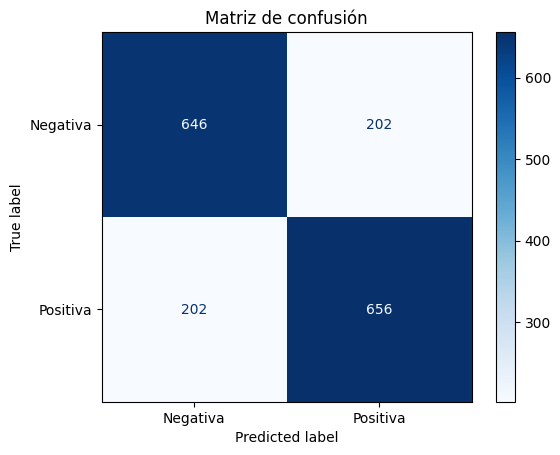

In [27]:
# El modelo predice el sentimiento de las reseñas que nunca vio
y_pred = modelo.predict(X_test_vec)

# Accuracy: porcentaje de reseñas clasificadas correctamente
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.2%}")

# Matriz de confusión: muestra dónde acierta y dónde se equivoca
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativa", "Positiva"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

In [30]:
# Tomamos ejemplos reales del conjunto de prueba
ejemplos = X_test.reset_index(drop=True)
etiquetas_reales = y_test.reset_index(drop=True)
predicciones = modelo.predict(X_test_vec)

def mostrar_ejemplo(indice, tipo):
    texto = ejemplos[indice]
    real = "Positiva" if etiquetas_reales[indice] == 1 else "Negativa"
    pred = "Positiva" if predicciones[indice] == 1 else "Negativa"
    resultado = "CORRECTO" if real == pred else "INCORRECTO"
    print(f"--- Ejemplo {tipo} ---")
    print(f"Reseña: {texto}")
    print(f"Etiqueta real: {real}")
    print(f"Predicción:    {pred}")
    print(f"Resultado:     {resultado}")
    print()

# 1. Bien clasificado — busca el primero donde acertó
for i in range(len(predicciones)):
    if predicciones[i] == etiquetas_reales[i]:
        mostrar_ejemplo(i, "bien clasificado")
        break

# 2. Mal clasificado — busca el primero donde se equivocó
for i in range(len(predicciones)):
    if predicciones[i] != etiquetas_reales[i]:
        mostrar_ejemplo(i, "mal clasificado")
        break

# 3. Dudoso — probabilidad más cercana a 0.5
probabilidades = modelo.predict_proba(X_test_vec)
idx_dudoso = abs(probabilidades[:, 1] - 0.5).argmin()
mostrar_ejemplo(idx_dudoso, "dudoso (ambiguo)")

--- Ejemplo bien clasificado ---
Reseña: so we got ten little indians meets friday the 13th by way of clean and sober , filmed on the set of carpenter's the thing and loaded with actors you're most likely to find on the next inevitable incarnation of the love boat .
Etiqueta real: Negativa
Predicción:    Negativa
Resultado:     CORRECTO

--- Ejemplo mal clasificado ---
Reseña: it would take a complete moron to foul up a screen adaptation of oscar wilde's classic satire .
Etiqueta real: Positiva
Predicción:    Negativa
Resultado:     INCORRECTO

--- Ejemplo dudoso (ambiguo) ---
Reseña: at its best , queen is campy fun like the vincent price horror classics of the '60s . at its worst , it implodes in a series of very bad special effects .
Etiqueta real: Negativa
Predicción:    Negativa
Resultado:     CORRECTO

